# Acquisition Function Output Analysis

Load a saved active-learning `output_dict` HDF5 file and start with the mean test reduced-error plot.

In [1]:
print("hello world")

hello world


In [2]:
%matplotlib inline

from pathlib import Path
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


cwd = Path.cwd()
stm_dir = cwd / "notebooks" / "PFM" if (cwd / "notebooks" / "PFM").exists() else cwd
#results_dir = Path("/content/drive/MyDrive/active_learning_results_1.8")
results_dir = stm_dir / "data"  / "BEPS_data" / "beps_active_learning_1d5um_ms"

h5_files = sorted(results_dir.glob("*.h5"), key=lambda path: path.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError(f"No .h5 files found in {results_dir}")


# By default, analyze the newest saved acquisition result. Replace this with
# a specific Path(...) if you want to load a different run.
output_file = h5_files[-1]




error_type = "L1"  # "L1", "L2", or "cos"
acquisition_iterations = 50
num_new_points = 5
output_file = results_dir / (
    f"al_FNO_attn_{error_type}_WS24_latent5_appendinterpolate_"
    f"{acquisition_iterations}iters_{num_new_points}pts_randomacq.h5"
)


In [3]:
def plot_reduced_errors_or_scales(errors, coords_reduced, which="errors", aq_indices=None, ax=None):
    xs = coords_reduced[:, 0]
    ys = coords_reduced[:, 1]
    scales = coords_reduced[:, 2]

    if which == "errors":
        sc = ax.scatter(xs, ys, c=errors, s=80, cmap="viridis")
        plt.colorbar(sc, ax=ax, label="Minimum Error")
    elif which == "scales":
        sc = ax.scatter(xs, ys, c=scales, s=80, cmap="viridis")
        plt.colorbar(sc, ax=ax, label="Best Scale")

    ax.set_aspect("equal")
    ax.set_xlabel("x", fontsize=16)
    ax.set_ylabel("y", fontsize=16)
    ax.tick_params

    if aq_indices is not None and len(aq_indices) > 0 and which == "errors":
        aq_indices = np.asarray(aq_indices, dtype=int)
        ax.scatter(xs[aq_indices], ys[aq_indices], marker="x", s=120, linewidths=2, label="Acquisition points")
        ax.legend()

def plot_group(title, file_list):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, output_file in enumerate(file_list):
        output_dict = load_h5_ragged(output_file)

        errors = np.asarray(output_dict["reduced_errors"][-1])
        coords = np.asarray(output_dict["reduced_coords"][-1])

        model_type, acquisition = parse_model_and_acq(output_file.stem)

        ax_err = axes[2*i]
        ax_scale = axes[2*i + 1]

        plot_reduced_errors_or_scales(errors, coords, which="errors", ax=ax_err)
        plot_reduced_errors_or_scales(errors, coords, which="scales", ax=ax_scale)

        ax_err.set_title(f"{model_type}-{acquisition}", fontsize=14)
        ax_scale.set_title(f"{model_type}-{acquisition}", fontsize=14)

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()



def parse_model_and_acq(fname):
    model_type = fname.split("beps_al_")[1].split("_L1")[0]
    acquisition = fname.split("_")[-1].replace("acq", "")
    return model_type, acquisition



def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for name in sorted(group.keys(), key=lambda x: int(x)):
                values.append(group[name][()])

            data_dict[key] = values

    return data_dict


def infer_num_new_points(output_dict, output_file, fallback=5):
    match = re.search(r"_(\d+)pts_", output_file.name)
    if match:
        return int(match.group(1))

    train_indices = output_dict.get("train_indices", [])
    if len(train_indices) > 1:
        return int(len(train_indices[1]) - len(train_indices[0]))

    return fallback




In [5]:
from pathlib import Path

results_dir = Path("/Users/8ij/nnerror/NN_Error/notebooks/PFM/data/BEPS_data/beps_active_learning_1d5um_ms")

h5_files = sorted(results_dir.glob("*.h5"), key=lambda path: path.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError(f"No .h5 files found in {results_dir}")

output_file = h5_files[-1]
print("Loading:", output_file)

output_dict = load_h5_ragged(output_file)
{key: len(value) for key, value in output_dict.items()}


Loading: /Users/8ij/nnerror/NN_Error/notebooks/PFM/data/BEPS_data/beps_active_learning_1d5um_ms/beps_al_im2spec_attn_L1_WS24_latent5_appendpad_50iters_5pts_randomacq.h5


{'im2spec_test_mismatches': 50,
 'pred_error_test': 50,
 'predicted_errors_all': 50,
 'reduced_coords': 50,
 'reduced_errors': 50,
 'reduced_errors_im2spec': 50,
 'test_indices': 50,
 'train_indices': 50}

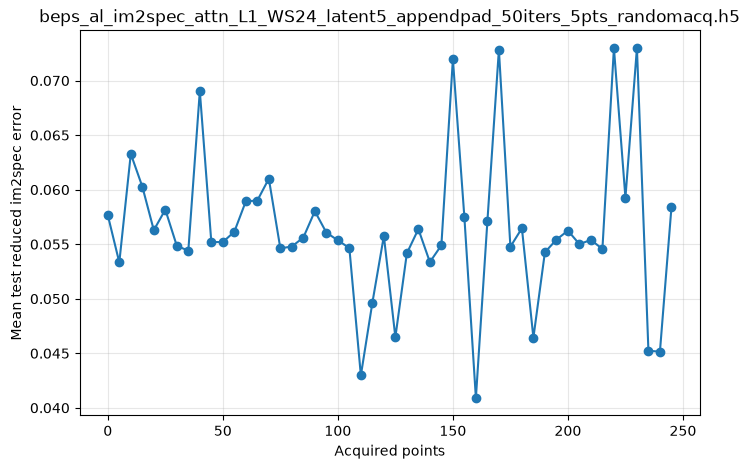

In [6]:


train_indices_arr = output_dict["train_indices"]
test_indices_arr = [indices.astype(int) for indices in output_dict["test_indices"]]
reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

num_saved_iterations = len(reduced_errors_arr)
points_per_iteration = infer_num_new_points(output_dict, output_file)

test_reduced_errors = [
    reduced_errors_arr[i][test_indices_arr[i]]
    for i in range(num_saved_iterations)
]

mean_test_reduced_errors = [
    np.mean(test_reduced_errors[i])
    for i in range(num_saved_iterations)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(num_saved_iterations) * points_per_iteration,
    mean_test_reduced_errors,
    marker="o",
)
ax.set_xlabel("Acquired points")
ax.set_ylabel("Mean test reduced im2spec error")
ax.set_title(Path(output_file).name)
ax.grid(True, alpha=0.3)
plt.show()

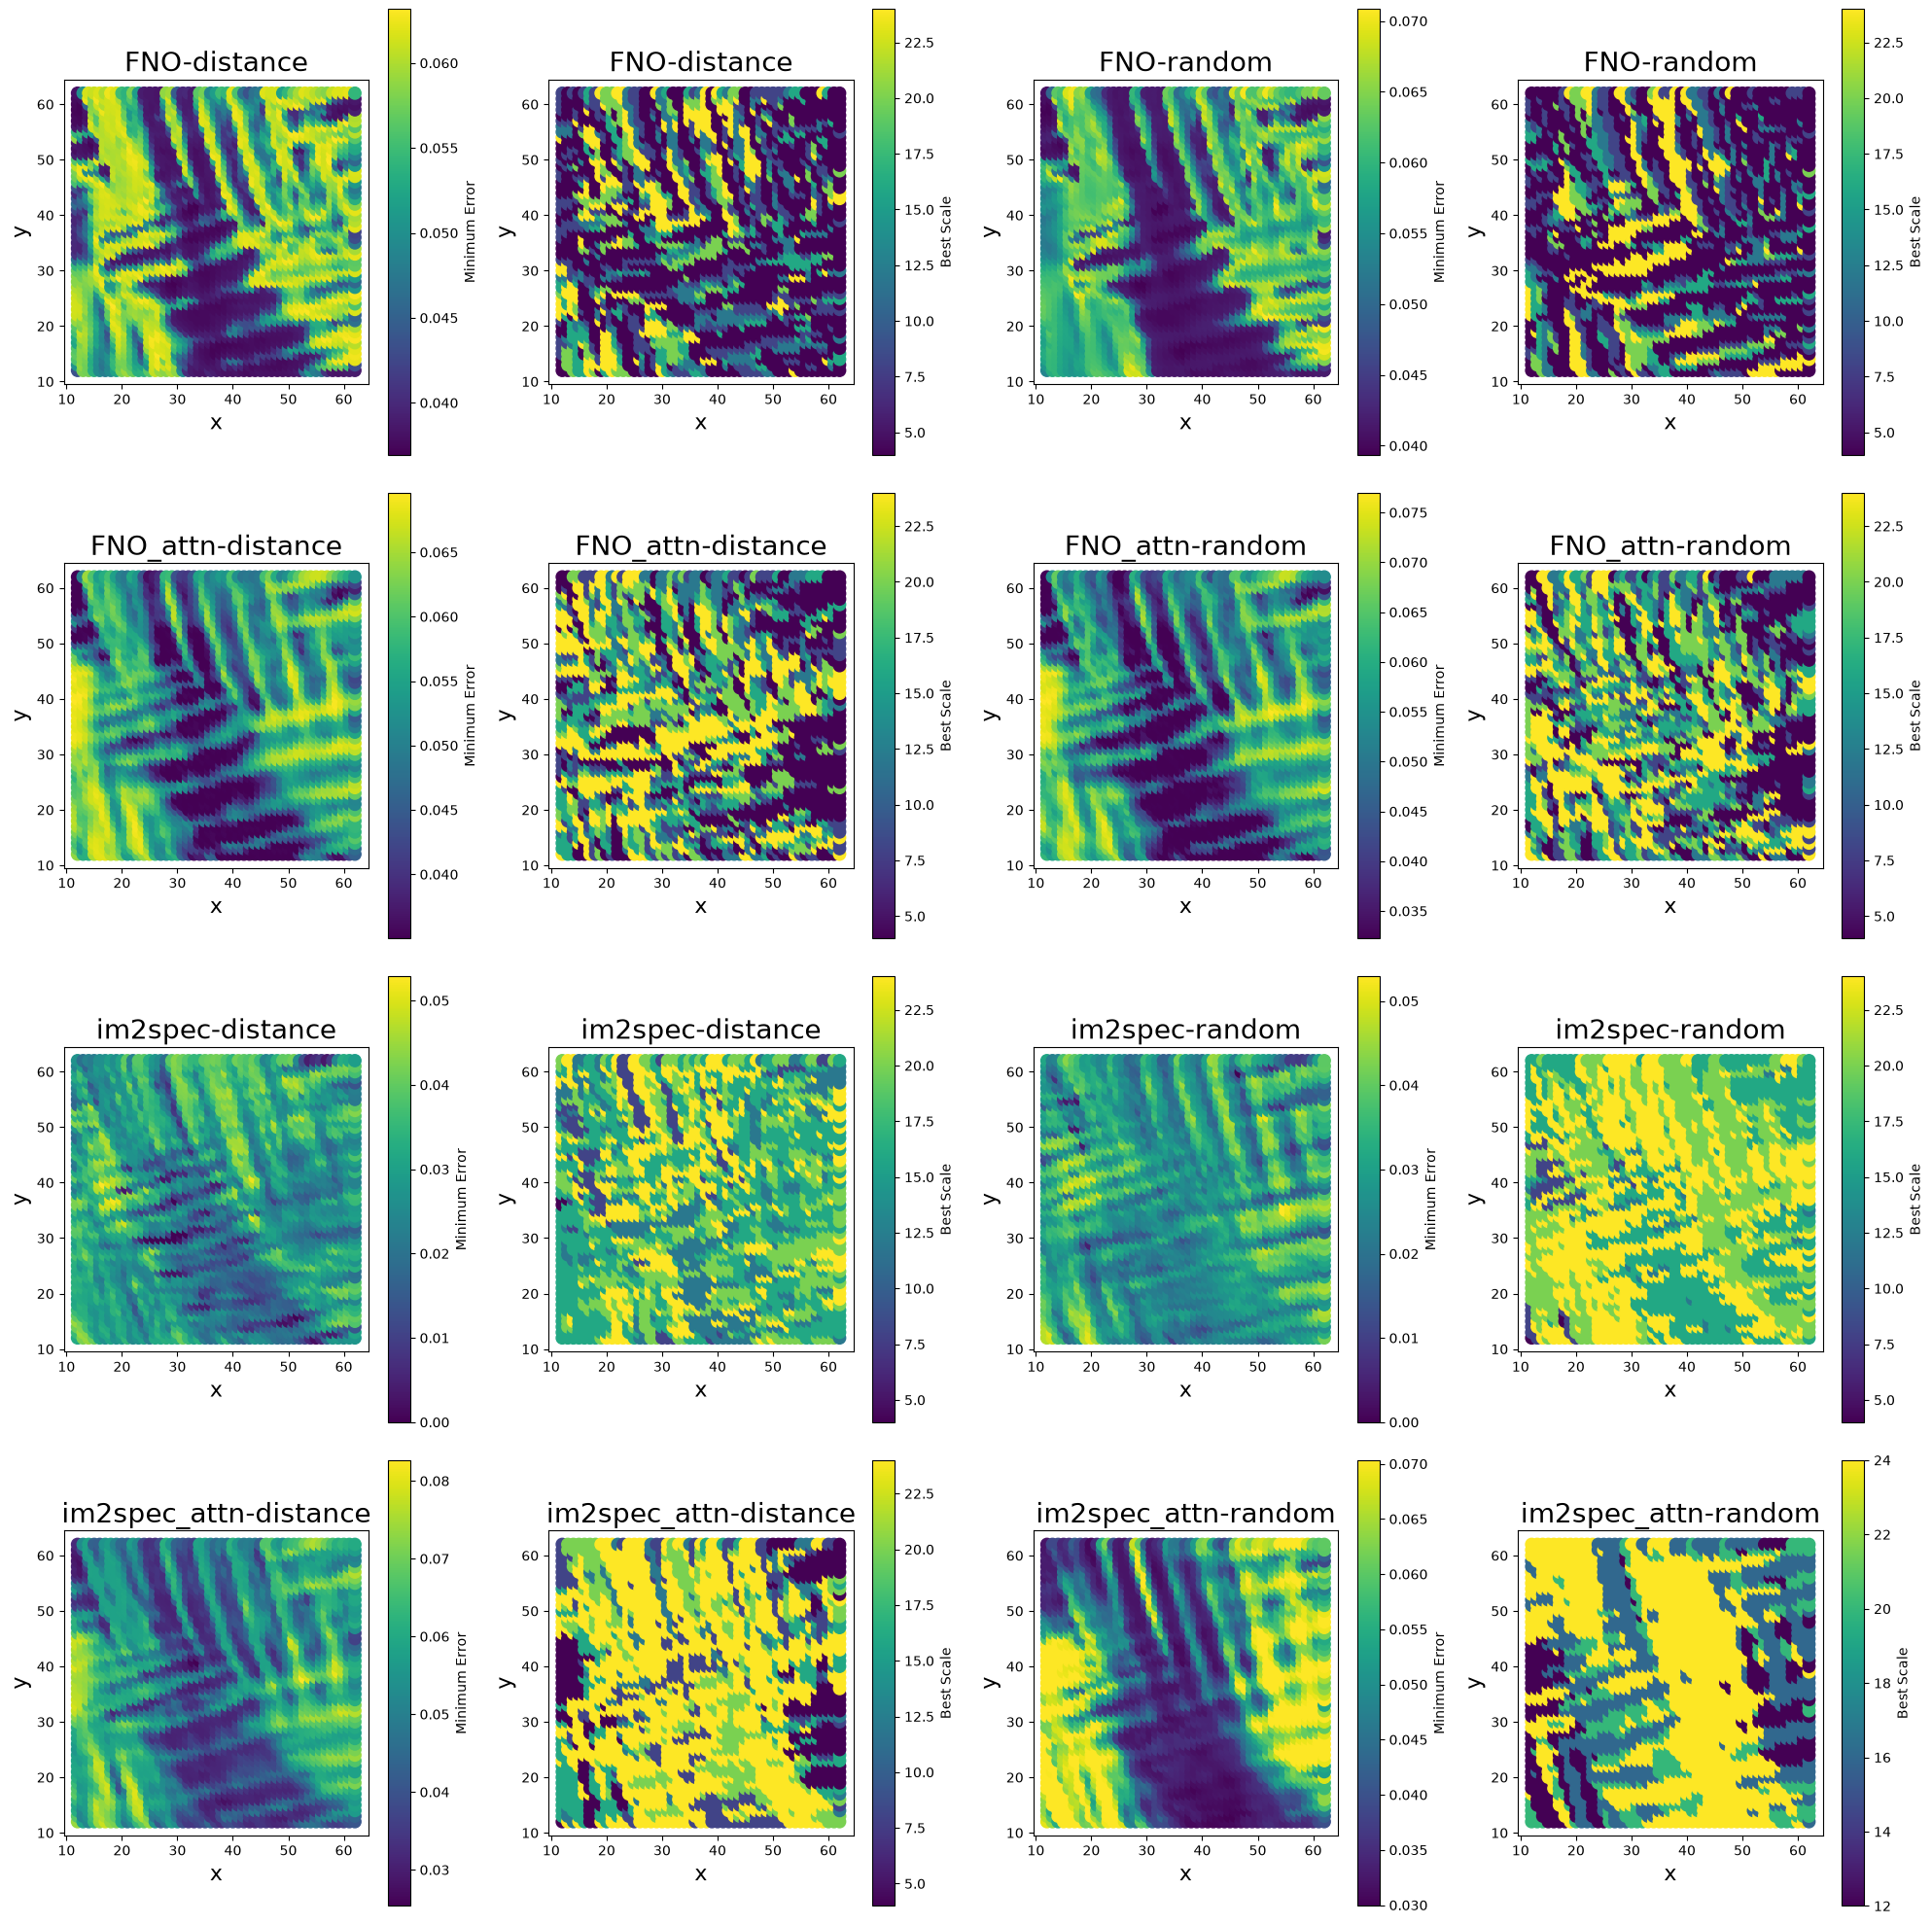

In [7]:
plot_iteration = -1
error_key = "reduced_errors"

h5_files = sorted(results_dir.glob("*.h5"))

fig, axes = plt.subplots(4, 4, figsize=(20, 20))  # 4x4 grid
axes = axes.flatten()  # flatten to 1D array of 16 axes

for i, output_file in enumerate(h5_files):
    output_dict = load_h5_ragged(output_file)

    reduced_errors_to_plot = np.asarray(output_dict[error_key][plot_iteration])
    reduced_coords_to_plot = np.asarray(output_dict["reduced_coords"][plot_iteration])

    fname = output_file.stem
    model_type = fname.split("beps_al_")[1].split("_L1")[0]
    acquisition = fname.split("_")[-1].replace("acq", "")

    # Assign two consecutive axes per model
    ax_err = axes[2*i]
    ax_scale = axes[2*i + 1]

    plot_reduced_errors_or_scales(reduced_errors_to_plot, reduced_coords_to_plot, which="errors", ax=ax_err)
    plot_reduced_errors_or_scales(reduced_errors_to_plot, reduced_coords_to_plot, which="scales", ax=ax_scale)

    # Title both panels with the same model-acquisition label
    ax_err.set_title(f"{model_type}-{acquisition}", fontsize=20)
    ax_scale.set_title(f"{model_type}-{acquisition}", fontsize=20)

plt.tight_layout()
plt.show()


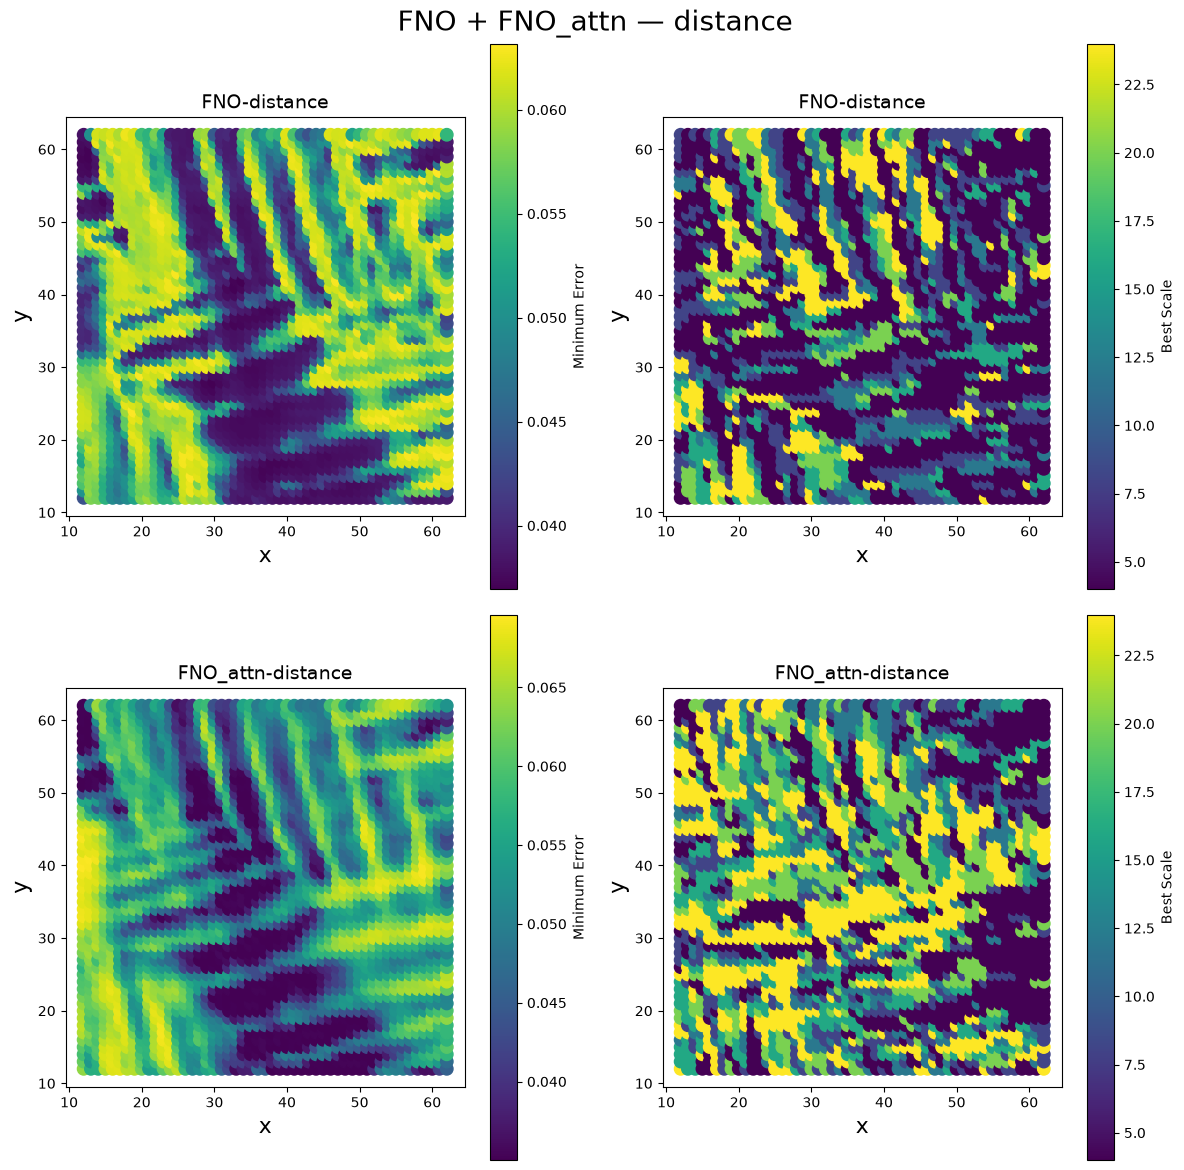

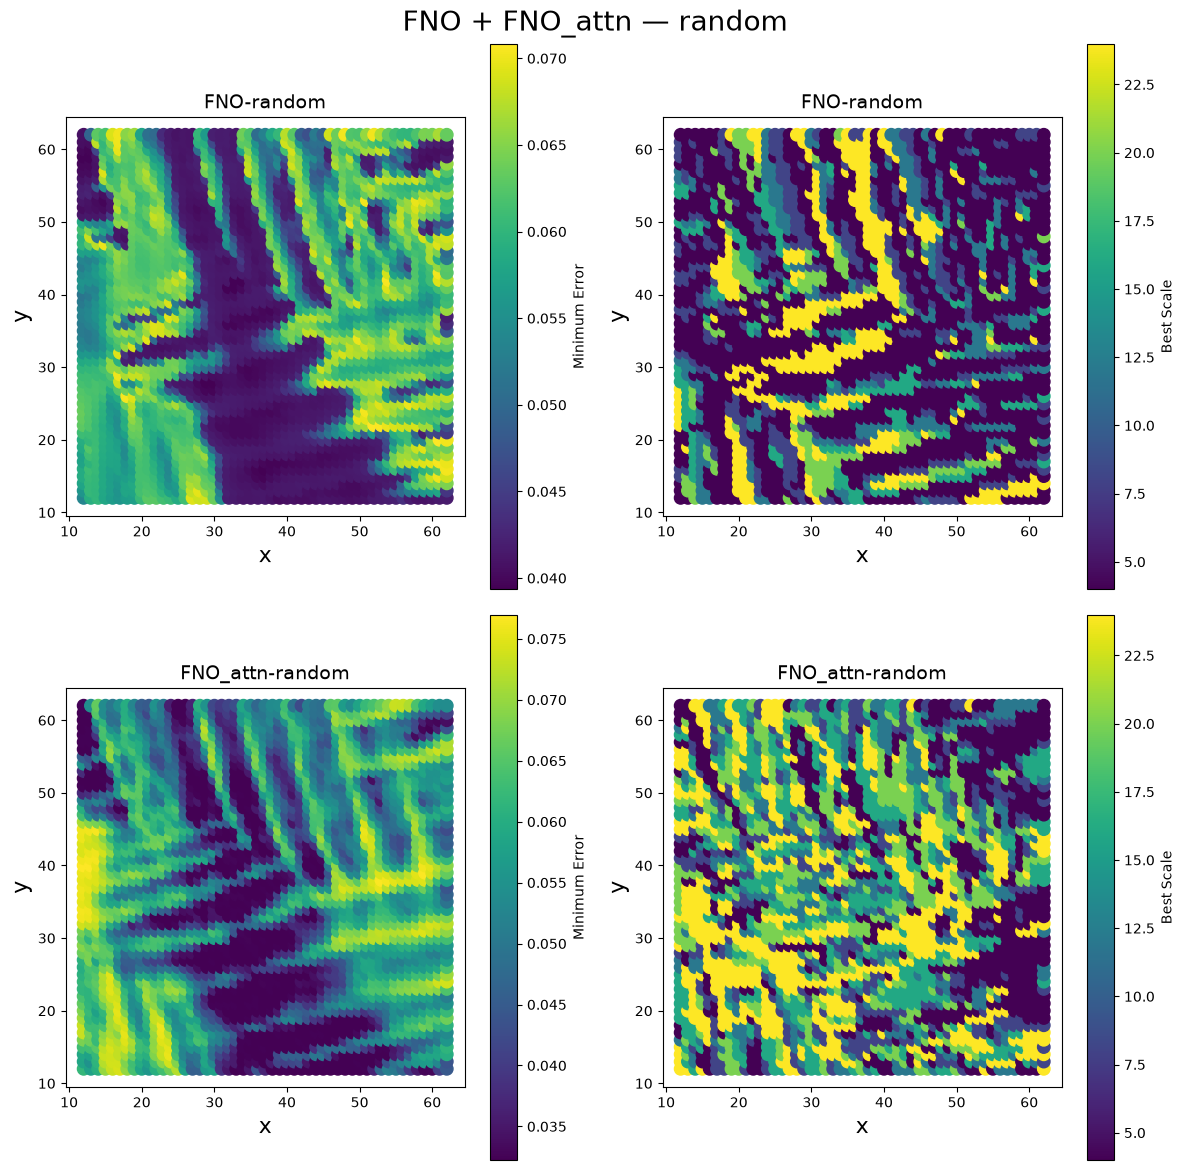

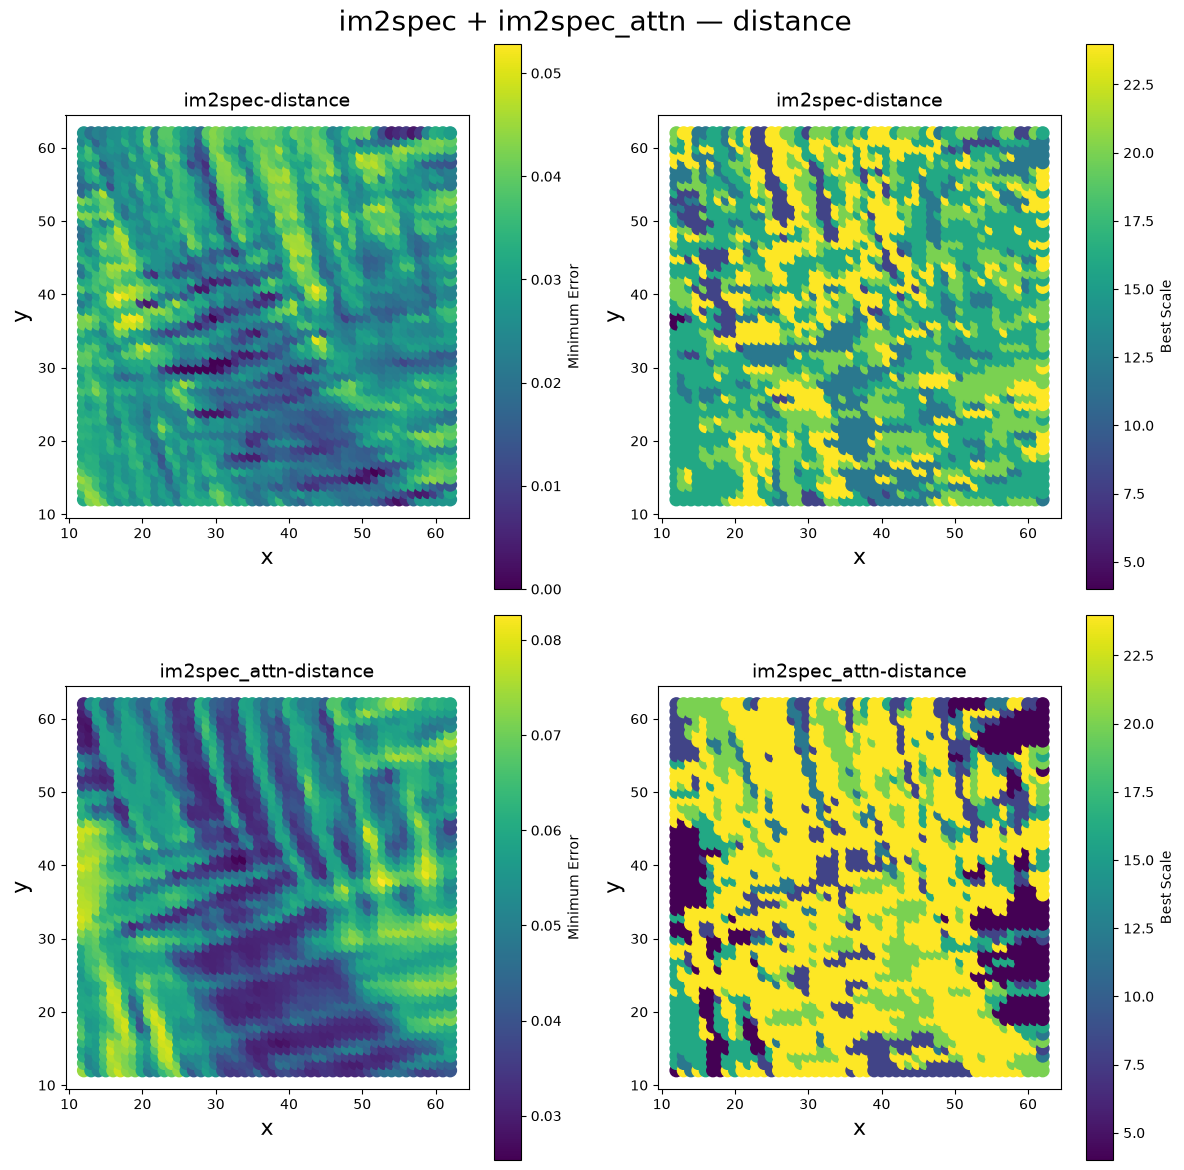

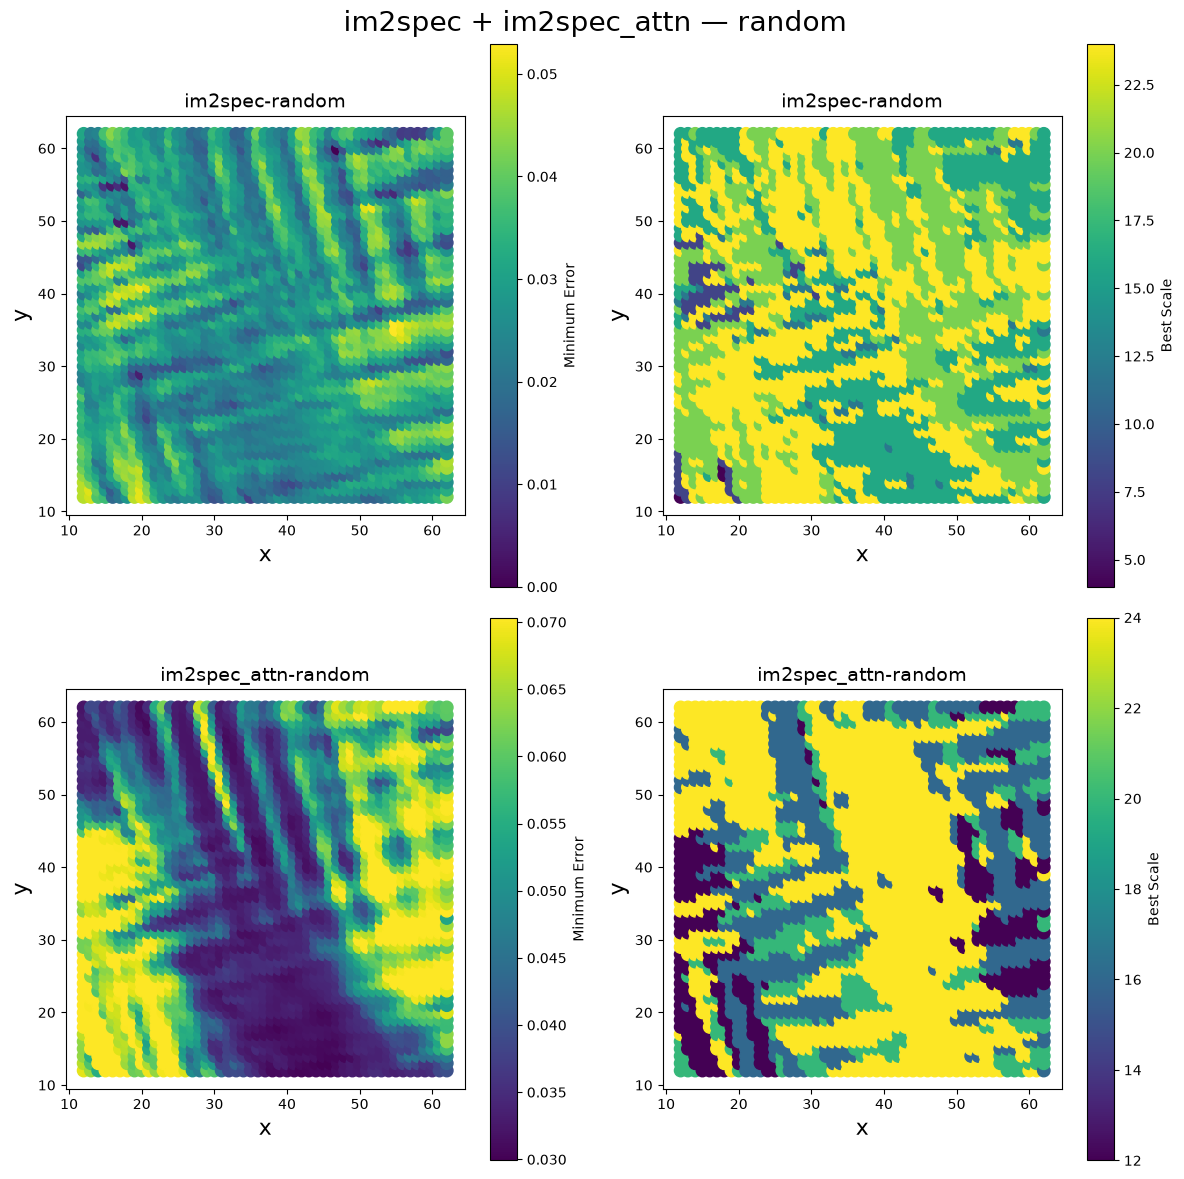

In [8]:
groups = {
    "fno_distance": [],
    "fno_random": [],
    "im2spec_distance": [],
    "im2spec_random": []
}

for f in h5_files:
    fname = f.stem
    model_type, acquisition = parse_model_and_acq(fname)

    if "FNO" in model_type:
        if acquisition == "distance":
            groups["fno_distance"].append(f)
        elif acquisition == "random":
            groups["fno_random"].append(f)

    if "im2spec" in model_type:
        if acquisition == "distance":
            groups["im2spec_distance"].append(f)
        elif acquisition == "random":
            groups["im2spec_random"].append(f)



plot_group("FNO + FNO_attn — distance", groups["fno_distance"])
plot_group("FNO + FNO_attn — random", groups["fno_random"])
plot_group("im2spec + im2spec_attn — distance", groups["im2spec_distance"])
plot_group("im2spec + im2spec_attn — random", groups["im2spec_random"])



# Compare with random.

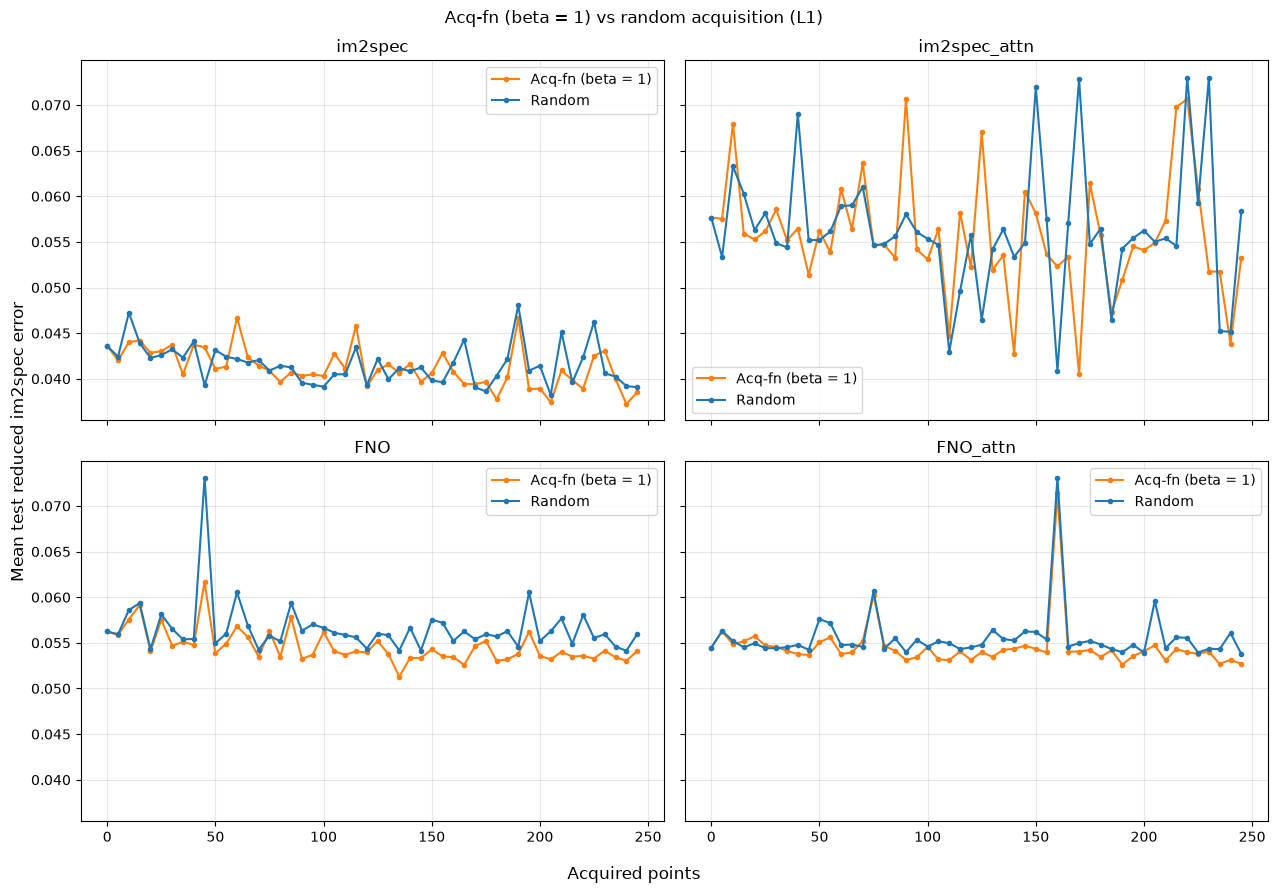

In [11]:
def calculate_mean_test_reduced_im2spec_error(output_dict):
    reduced_errors = output_dict["reduced_errors_im2spec"]
    test_indices = output_dict["test_indices"]

    if len(reduced_errors) != len(test_indices):
        raise ValueError(
            "reduced_errors_im2spec and test_indices have different iteration counts"
        )

    return np.asarray([
        np.mean(np.asarray(errors)[np.asarray(indices, dtype=int)])
        for errors, indices in zip(reduced_errors, test_indices)
    ])


model_configs = {
    "im2spec": "appendpad",
    "im2spec_attn": "appendpad",
    "FNO": "appendinterpolate",
    "FNO_attn": "appendinterpolate",
}
acquisition_colors = {"random": "tab:blue", "distance": "tab:orange"}
acquisition_labels = {
    "random": "Random",
    "distance": "Acq-fn (beta = 1)",
}
comparison_results = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, append_mode) in zip(axes.flat, model_configs.items()):
    comparison_results[model_type] = {}

    for acquisition in ("distance", "random"):
        output_file = results_dir / (
            f"beps_al_{model_type}_{error_type}_WS24_latent5_{append_mode}_"
            f"{acquisition_iterations}iters_{num_new_points}pts_"
            f"{acquisition}acq.h5"
        )
        if not output_file.exists():
            raise FileNotFoundError(output_file)

        output_dict = load_h5_ragged(output_file)
        mean_test_reduced_im2spec_error = (
            calculate_mean_test_reduced_im2spec_error(output_dict)
        )
        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = (
            np.arange(len(mean_test_reduced_im2spec_error))
            * points_per_iteration
        )

        comparison_results[model_type][acquisition] = {
            "output_file": output_file,
            "output_dict": output_dict,
            "mean_test_reduced_im2spec_error": (
                mean_test_reduced_im2spec_error
            ),
        }

        ax.plot(
            acquired_points,
            mean_test_reduced_im2spec_error,
            marker="o",
            markersize=3,
            color=acquisition_colors[acquisition],
            label=acquisition_labels[acquisition],
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Mean test reduced im2spec error")
fig.suptitle(f"Acq-fn (beta = 1) vs random acquisition ({error_type})")
fig.tight_layout()
plt.show()

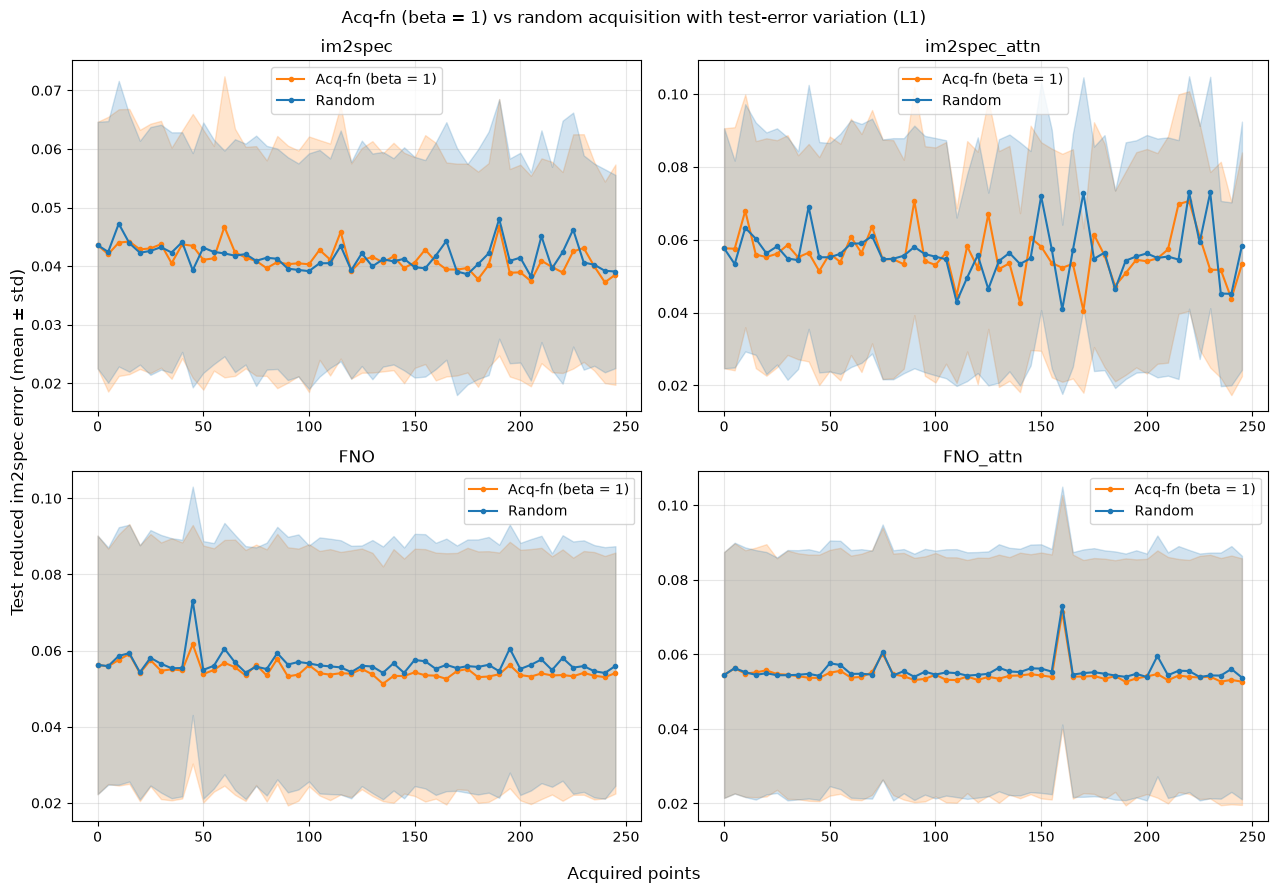

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (model_type, acquisition_results) in zip(
    axes.flat, comparison_results.items()
):
    for acquisition, result in acquisition_results.items():
        output_dict = result["output_dict"]
        output_file = result["output_file"]

        test_reduced_im2spec_errors = [
            np.asarray(errors)[np.asarray(indices, dtype=int)]
            for errors, indices in zip(
                output_dict["reduced_errors_im2spec"],
                output_dict["test_indices"],
            )
        ]
        mean_errors = result["mean_test_reduced_im2spec_error"]
        std_errors = np.asarray([
            np.std(errors) for errors in test_reduced_im2spec_errors
        ])
        result["std_test_reduced_im2spec_error"] = std_errors

        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = np.arange(len(mean_errors)) * points_per_iteration

        mean_line = ax.plot(
            acquired_points,
            mean_errors,
            marker="o",
            markersize=3,
            color=acquisition_colors[acquisition],
            label=acquisition_labels[acquisition],
        )[0]
        ax.fill_between(
            acquired_points,
            mean_errors - std_errors,
            mean_errors + std_errors,
            color=mean_line.get_color(),
            alpha=0.2,
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Test reduced im2spec error (mean ± std)")
fig.suptitle(
    f"Acq-fn (beta = 1) vs random acquisition with test-error variation "
    f"({error_type})"
)
fig.tight_layout()
plt.show()


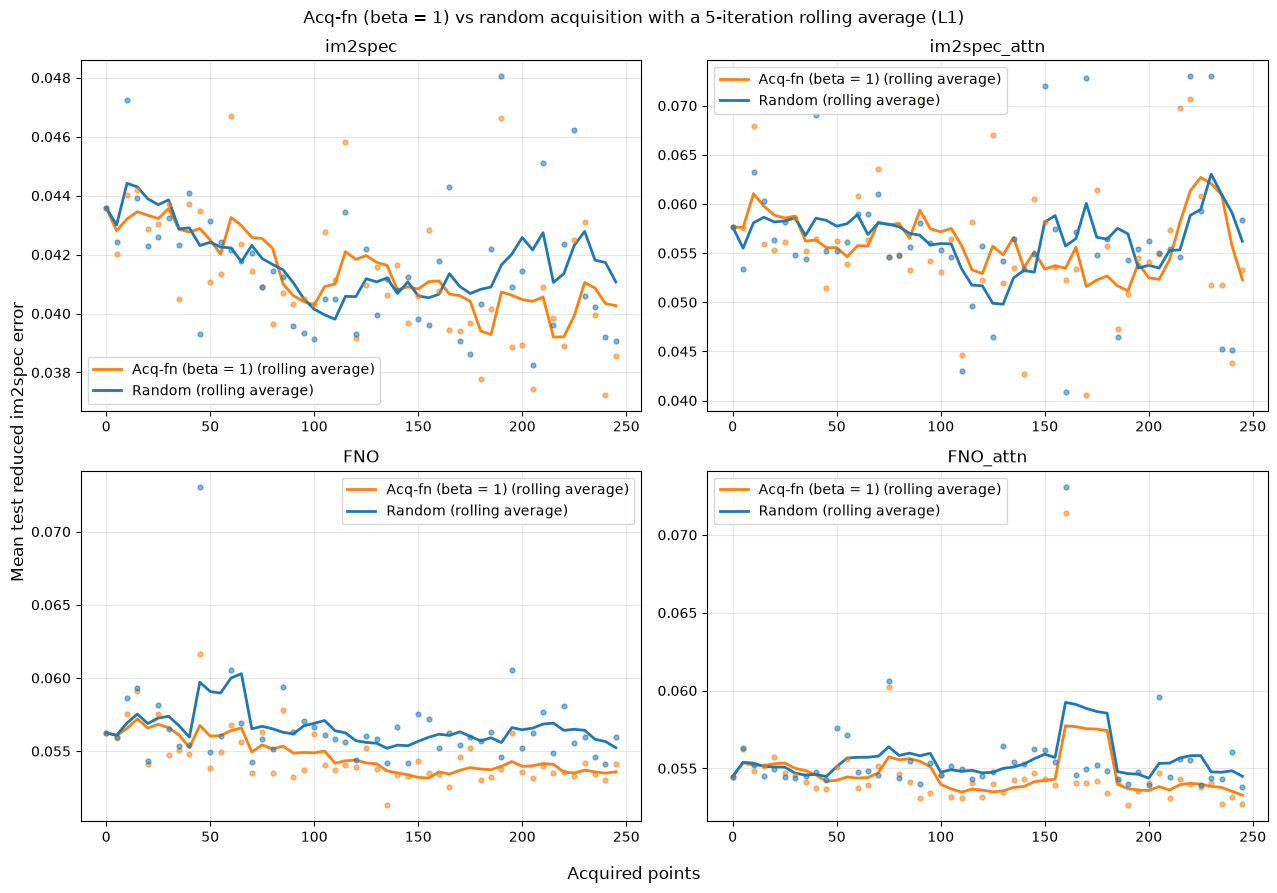

In [13]:

def rolling_average(array, window = 5):
  p_average = []

  array = np.array(array).squeeze()
  for i in range(len(array)):
    if i+1 < window:
      k = i+1
    else:
      k = window

    sum = 0
    for j in range(k):
      sum += array[i-j]

    p_average.append(sum/k)

  p_average = np.array(p_average).squeeze()

  return p_average


rolling_window = 5

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (model_type, acquisition_results) in zip(
    axes.flat, comparison_results.items()
):
    for acquisition, result in acquisition_results.items():
        output_dict = result["output_dict"]
        output_file = result["output_file"]
        mean_errors = result["mean_test_reduced_im2spec_error"]

        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = np.arange(len(mean_errors)) * points_per_iteration
        rolling_mean_errors = rolling_average(
            mean_errors, window=rolling_window
        )

        rolling_line = ax.plot(
            acquired_points,
            rolling_mean_errors,
            linewidth=2,
            color=acquisition_colors[acquisition],
            label=f"{acquisition_labels[acquisition]} (rolling average)",
        )[0]
        ax.scatter(
            acquired_points,
            mean_errors,
            color=rolling_line.get_color(),
            s=12,
            alpha=0.55,
            zorder=3,
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Mean test reduced im2spec error")
fig.suptitle(
    f"Acq-fn (beta = 1) vs random acquisition with a "
    f"{rolling_window}-iteration "
    f"rolling average ({error_type})"
)
fig.tight_layout()
plt.show()


In [16]:
import requests

def extract_beps_data():
    """
    Extracts BEPS data from h5 file.
    """

    # Replace the wget line with this:
    url = "https://www.dropbox.com/scl/fi/sitkzwu8uk04ygru8edf1/BEPS_1d5um_0001.h5?rlkey=oz7b9zue2ftxiix6e5mal0szh&dl=1"
    dest = "BEPS.h5"

    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

    h5_f = h5py.File(dest, "r")

    sho_mat = h5_f["Measurement_000/Channel_000/Raw_Data-SHO_Fit_001/Fit"]
    spec_val = h5_f["Measurement_000/Channel_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values"]
    pos_inds = h5_f["Measurement_000/Channel_000/Position_Indices"]

    pos_dim_sizes = [
        np.max(pos_inds[:, 0]) + 1,
        np.max(pos_inds[:, 1]) + 1,
    ]

    sho_mat_ndim = sho_mat[:].reshape(pos_dim_sizes[0], pos_dim_sizes[1], -1)

    amp_mat_ndim = sho_mat_ndim["Amplitude [V]"]
    phase_mat_ndim = sho_mat_ndim["Phase [rad]"]
    fre_mat_ndim = sho_mat_ndim["Frequency [Hz]"]
    q_mat_ndim = sho_mat_ndim["Quality Factor"]

    topo = np.mean(amp_mat_ndim, axis=2)

    return (
        sho_mat_ndim,
        amp_mat_ndim,
        phase_mat_ndim,
        fre_mat_ndim,
        q_mat_ndim,
        spec_val,
        pos_inds,
        pos_dim_sizes,
        topo,
    )


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# List all .h5 files in your results_dir
h5_files = sorted(results_dir.glob("*.h5"))

# Load BEPS structural image once
(
    sho_mat_ndim,
    amp_mat_ndim,
    phase_mat_ndim,
    fre_mat_ndim,
    q_mat_ndim,
    spec_val,
    pos_inds,
    pos_dim_sizes,
    topo,
) = extract_beps_data()


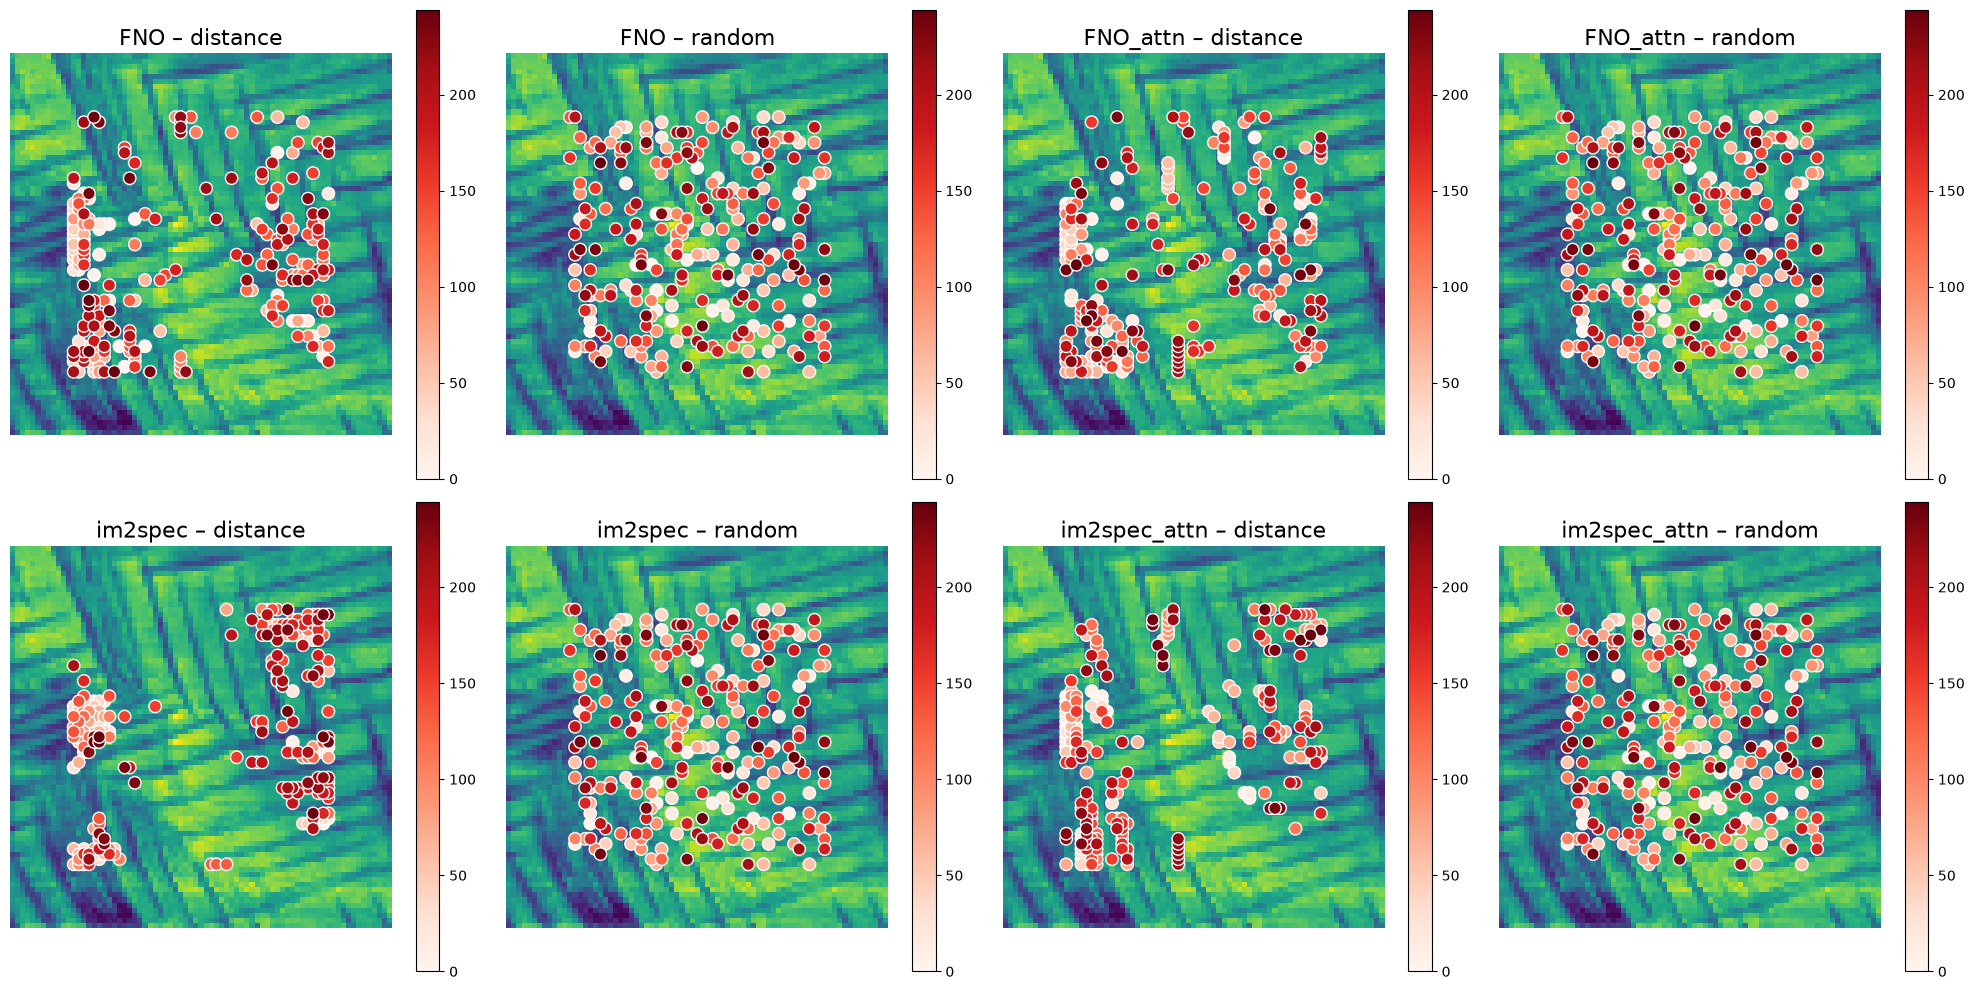

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, output_file in zip(axes.ravel(), h5_files):
    output_dict = load_h5_ragged(output_file)

    train_sets = output_dict["train_indices"]

    acq_order = []
    for t in range(1, len(train_sets)):
        prev = set(train_sets[t-1])
        curr = set(train_sets[t])
        new = list(curr - prev)
        acq_order.extend(new)

    acq_order = np.asarray(acq_order, dtype=int)

    coords = np.asarray(output_dict["reduced_coords"][-1])
    acquired_coords = coords[acq_order]


    acq_seq = np.arange(len(acq_order))

    # Plot topo + acquisition points
    ax.imshow(topo, origin="lower", aspect="equal")
    sc = ax.scatter(
        acquired_coords[:, 0],
        acquired_coords[:, 1],
        c=acq_seq,
        cmap="Reds",
        s=80,
        edgecolors="white",
        linewidths=1,
    )

    # --- Parse filename for model type and acquisition ---
    fname = output_file.stem

    if "beps_al_" in fname and "_L1" in fname:
        model_type = fname.split("beps_al_")[1].split("_L1")[0]
    else:
        model_type = "Unknown"

    acquisition = fname.split("_")[-1].replace("acq", "")

    ax.set_title(f"{model_type} – {acquisition}", fontsize=16)
    ax.axis("off")

    # Colorbar for this subplot
    fig.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()
